In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        print(root)
        print("Files:", len(files))
        print("Examples:", files[:5])

/kaggle/input/datasets/anoukstein/spider-mri-spine-t2-png/data/images
Files: 3535
Examples: ['10_11.png', '191_01.png', '210_06.png', '239_03.png', '61_01.png']
/kaggle/input/datasets/anoukstein/spider-mri-spine-t2-png/data/masks
Files: 3535
Examples: ['10_11.png', '191_01.png', '210_06.png', '239_03.png', '61_01.png']


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


MRI images: 3535
Masks: 3535
Matching filenames: True


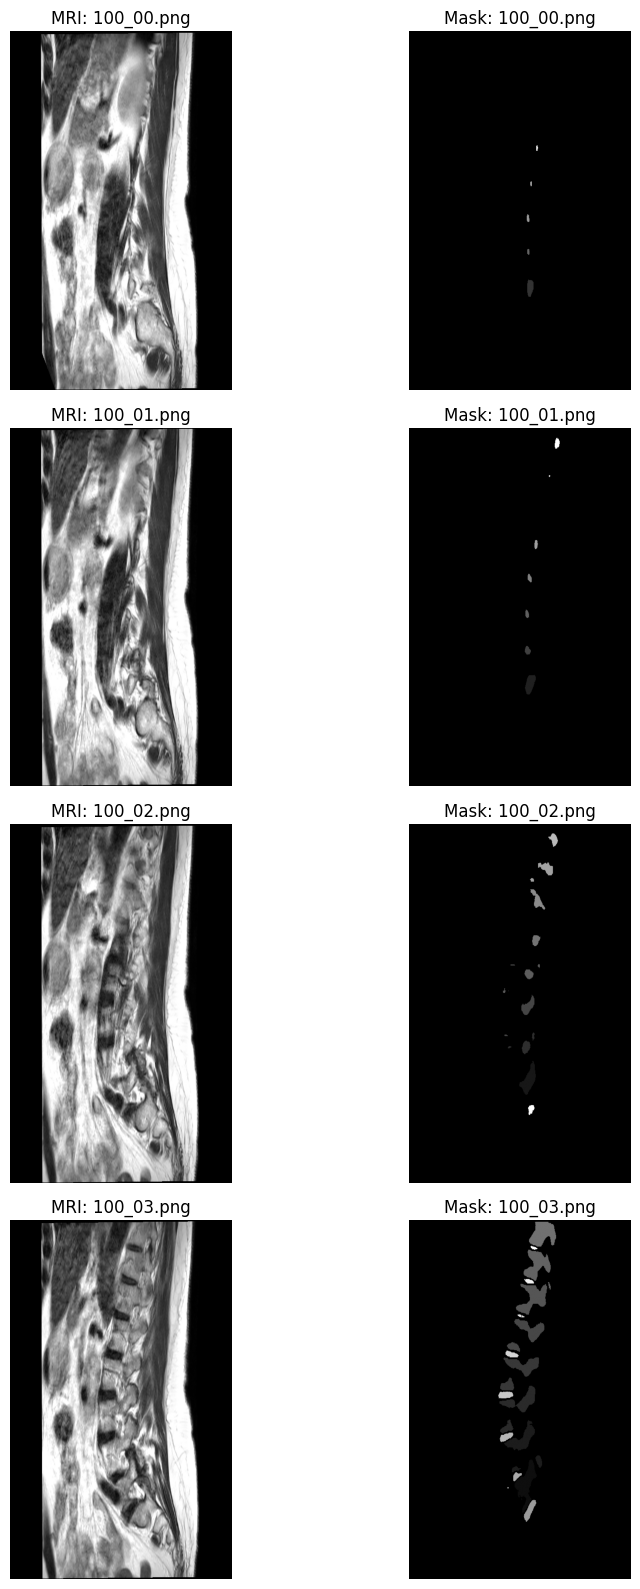

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = "/kaggle/input/datasets/anoukstein/spider-mri-spine-t2-png/data/images"
MASK_DIR  = "/kaggle/input/datasets/anoukstein/spider-mri-spine-t2-png/data/masks"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(".png")
])

mask_files = sorted([
    f for f in os.listdir(MASK_DIR)
    if f.lower().endswith(".png")
])

print("MRI images:", len(image_files))
print("Masks:", len(mask_files))

# Verify filenames match
print("Matching filenames:",
      image_files == mask_files)

# Show 4 examples
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

for i in range(4):
    img_name = image_files[i]

    image = cv2.imread(
        os.path.join(IMAGE_DIR, img_name),
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.imread(
        os.path.join(MASK_DIR, img_name),
        cv2.IMREAD_GRAYSCALE
    )

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title(f"MRI: {img_name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Mask: {img_name}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# Keep image and mask together
train_files, val_files = train_test_split(
    image_files,
    test_size=0.20,
    random_state=42
)

print("Training images:", len(train_files))
print("Validation images:", len(val_files))

Training images: 2828
Validation images: 707


In [5]:
import cv2
import numpy as np
import os

# Take one sample
sample_name = train_files[0]

image = cv2.imread(
    os.path.join(IMAGE_DIR, sample_name),
    cv2.IMREAD_GRAYSCALE
)

mask = cv2.imread(
    os.path.join(MASK_DIR, sample_name),
    cv2.IMREAD_GRAYSCALE
)

print("Sample:", sample_name)
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("Image min/max:", image.min(), image.max())
print("Mask min/max:", mask.min(), mask.max())

print("Unique mask values:")
print(np.unique(mask)[:30])

Sample: 224_11.png
Image shape: (441, 379)
Mask shape: (441, 379)
Image min/max: 0 255
Mask min/max: 0 17
Unique mask values:
[ 0  1  2  3  4  5  6  7 11 12 13 14 15 16 17]


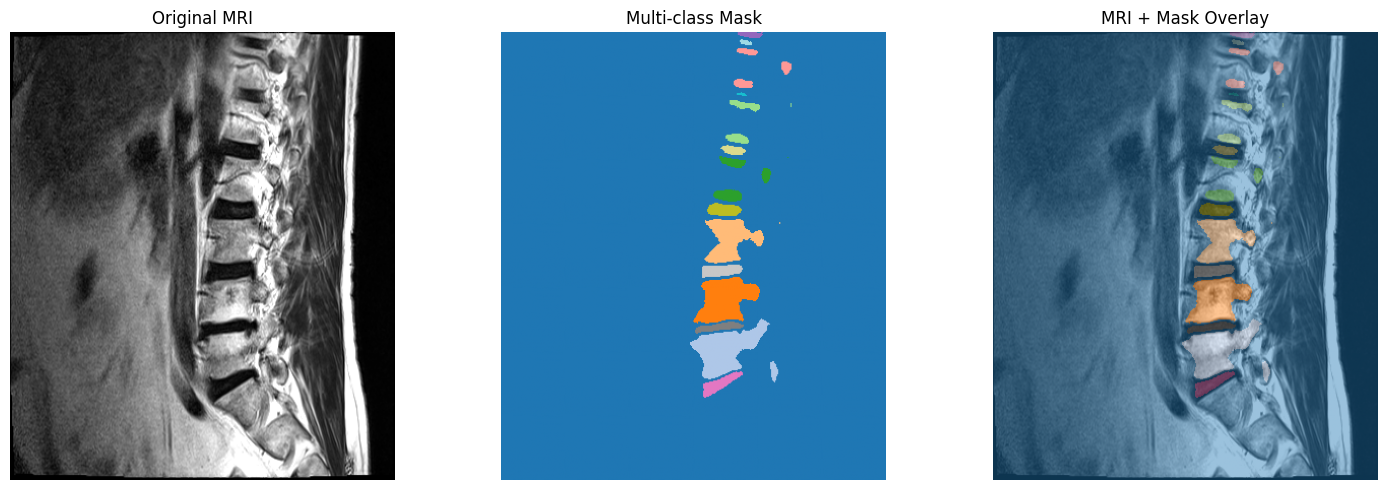

Labels present: [ 0  1  2  3  4  5  6  7 11 12 13 14 15 16 17]


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

sample_name = train_files[0]

image = cv2.imread(
    os.path.join(IMAGE_DIR, sample_name),
    cv2.IMREAD_GRAYSCALE
)

mask = cv2.imread(
    os.path.join(MASK_DIR, sample_name),
    cv2.IMREAD_GRAYSCALE
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original MRI")
axes[0].axis("off")

axes[1].imshow(mask, cmap="tab20", vmin=0, vmax=17)
axes[1].set_title("Multi-class Mask")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].imshow(mask, cmap="tab20", alpha=0.45, vmin=0, vmax=17)
axes[2].set_title("MRI + Mask Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Labels present:", np.unique(mask))

In [7]:
import os
import cv2
import numpy as np

all_labels = set()

# Check training masks
for filename in train_files:
    mask_path = os.path.join(MASK_DIR, filename)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    labels = np.unique(mask)
    all_labels.update(labels.tolist())

# Check validation masks
for filename in val_files:
    mask_path = os.path.join(MASK_DIR, filename)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    labels = np.unique(mask)
    all_labels.update(labels.tolist())

all_labels = sorted(all_labels)

print("All labels found:", all_labels)
print("Number of labels:", len(all_labels))

All labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of labels: 20


Images shape: (16, 256, 256, 1)
Masks shape: (16, 256, 256)
Image dtype: <dtype: 'float32'>
Mask dtype: <dtype: 'int32'>
Image range: 0.0 to 1.0
Mask labels in this batch:
[ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18]


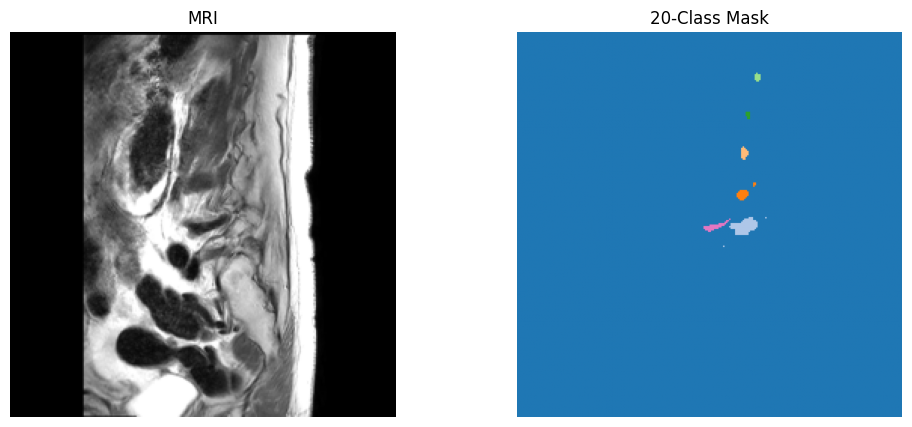

In [10]:
# Get one batch
images, masks = next(iter(train_dataset))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Image range:", tf.reduce_min(images).numpy(), "to", tf.reduce_max(images).numpy())

print("Mask labels in this batch:")
print(np.unique(masks.numpy()))

# Visualize one sample
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(images[0, :, :, 0], cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[0], cmap="tab20", vmin=0, vmax=19)
plt.title("20-Class Mask")
plt.axis("off")

plt.show()

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def conv_block(x, filters):
    x = layers.Conv2D(
        filters, 3,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters, 3,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x


def build_unet(input_shape=(256, 256, 1), num_classes=20):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = conv_block(p4, 512)

    # Decoder
    u6 = layers.Conv2DTranspose(
        256, 2, strides=2, padding="same"
    )(c5)
    u6 = layers.Concatenate()([u6, c4])
    c6 = conv_block(u6, 256)

    u7 = layers.Conv2DTranspose(
        128, 2, strides=2, padding="same"
    )(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = conv_block(u7, 128)

    u8 = layers.Conv2DTranspose(
        64, 2, strides=2, padding="same"
    )(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = conv_block(u8, 64)

    u9 = layers.Conv2DTranspose(
        32, 2, strides=2, padding="same"
    )(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = conv_block(u9, 32)

    # 20-class output
    outputs = layers.Conv2D(
        num_classes,
        1,
        activation="softmax",
        padding="same"
    )(c9)

    return keras.Model(inputs, outputs, name="Spine_UNet")


model = build_unet(
    input_shape=(IMG_SIZE, IMG_SIZE, 1),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "Spine_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,771,924 (29.65 MB)

 Trainable params: 7,766,036 (29.63 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [15]:
import tensorflow as tf
import numpy as np

# Class weights based on the pixel distribution
class_weights = np.array([
    0.05,   # 0
    1.0,    # 1
    1.0,    # 2
    1.0,    # 3
    1.0,    # 4
    1.0,    # 5
    1.0,    # 6
    1.5,    # 7
    2.0,    # 8
    4.0,    # 9
    1.0,    # 10
    1.5,    # 11
    1.5,    # 12
    1.5,    # 13
    1.5,    # 14
    1.5,    # 15
    2.0,    # 16
    2.0,    # 17
    3.0,    # 18
    4.0     # 19
], dtype=np.float32)


def weighted_ce_loss(y_true, y_pred):
    """
    Weighted categorical cross entropy.
    """

    y_true = tf.cast(y_true, tf.int32)

    # Convert class IDs to one-hot
    y_true_one_hot = tf.one_hot(
        y_true,
        depth=NUM_CLASSES
    )

    # Prevent log(0)
    y_pred = tf.clip_by_value(
        y_pred,
        1e-7,
        1.0 - 1e-7
    )

    # Cross entropy
    ce = -tf.reduce_sum(
        y_true_one_hot * tf.math.log(y_pred),
        axis=-1
    )

    # Get weight for each pixel's true class
    weights = tf.gather(
        class_weights,
        y_true
    )

    return tf.reduce_mean(ce * weights)


def dice_loss(y_true, y_pred):

    y_true = tf.cast(y_true, tf.int32)

    y_true_one_hot = tf.one_hot(
        y_true,
        depth=NUM_CLASSES
    )

    # Flatten
    y_true_flat = tf.reshape(
        y_true_one_hot,
        [-1, NUM_CLASSES]
    )

    y_pred_flat = tf.reshape(
        y_pred,
        [-1, NUM_CLASSES]
    )

    intersection = tf.reduce_sum(
        y_true_flat * y_pred_flat,
        axis=0
    )

    denominator = (
        tf.reduce_sum(y_true_flat, axis=0)
        +
        tf.reduce_sum(y_pred_flat, axis=0)
    )

    dice = (
        (2.0 * intersection + 1e-6)
        /
        (denominator + 1e-6)
    )

    # Ignore background for Dice loss
    dice_foreground = dice[1:]

    return 1.0 - tf.reduce_mean(dice_foreground)


def combined_loss(y_true, y_pred):

    ce = weighted_ce_loss(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)

    return 0.5 * ce + 0.5 * dice


print("Loss functions created successfully.")
print("Number of classes:", NUM_CLASSES)
print("Class weights:", class_weights)

Loss functions created successfully.
Number of classes: 20
Class weights: [0.05 1.   1.   1.   1.   1.   1.   1.5  2.   4.   1.   1.5  1.5  1.5
 1.5  1.5  2.   2.   3.   4.  ]


In [16]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss
)

print("Model compiled successfully.")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Loss: Weighted Cross-Entropy + Dice Loss")

Model compiled successfully.
Optimizer: Adam
Learning rate: 0.0001
Loss: Weighted Cross-Entropy + Dice Loss


In [17]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=1,
    verbose=1
)

2026-10-03 10:43:56.235910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:43:56.397644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:44:01.033434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:44:01.342356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:44:02.936798: E external/local_xla/xla/stream_

    176/Unknown 180s 627ms/step - loss: 0.6680

2026-10-03 10:46:23.282128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:46:23.519800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:46:25.621795: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:46:25.784037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:46:29.723097: E external/local_xla/xla/stream_

    177/Unknown 217s 829ms/step - loss: 0.6678

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-10-03 10:47:29.738824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:47:29.965439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 10:47:30.821765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing war

177/177 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - loss: 0.6307 - val_loss: 0.6466


In [18]:
# Rebuild datasets with explicit step counts

STEPS_PER_EPOCH = len(train_files) // BATCH_SIZE
VALIDATION_STEPS = len(val_files) // BATCH_SIZE

print("Steps per epoch:", STEPS_PER_EPOCH)
print("Validation steps:", VALIDATION_STEPS)

train_dataset_fixed = (
    train_dataset
    .repeat()
)

val_dataset_fixed = (
    val_dataset
    .repeat()
)

print("Training dataset fixed.")

Steps per epoch: 176
Validation steps: 44
Training dataset fixed.


In [19]:
def mean_dice(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)

    y_true_one_hot = tf.one_hot(
        y_true,
        depth=NUM_CLASSES
    )

    y_pred_labels = tf.argmax(
        y_pred,
        axis=-1
    )

    y_pred_one_hot = tf.one_hot(
        y_pred_labels,
        depth=NUM_CLASSES
    )

    # Ignore background
    y_true_one_hot = y_true_one_hot[..., 1:]
    y_pred_one_hot = y_pred_one_hot[..., 1:]

    intersection = tf.reduce_sum(
        y_true_one_hot * y_pred_one_hot,
        axis=[1, 2]
    )

    denominator = (
        tf.reduce_sum(y_true_one_hot, axis=[1, 2]) +
        tf.reduce_sum(y_pred_one_hot, axis=[1, 2])
    )

    dice = (
        (2.0 * intersection + 1e-6) /
        (denominator + 1e-6)
    )

    return tf.reduce_mean(dice)


def mean_iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)

    y_pred_labels = tf.argmax(
        y_pred,
        axis=-1,
        output_type=tf.int32
    )

    # Mean IoU across all 20 classes
    return tf.reduce_mean(
        tf.keras.metrics.MeanIoU(
            num_classes=NUM_CLASSES
        )(y_true, y_pred_labels)
    )


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        mean_dice,
        mean_iou
    ]
)

print("Model recompiled with Dice + IoU metrics.")

Model recompiled with Dice + IoU metrics.


In [20]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_spine_unet.keras",
    monitor="val_mean_dice",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_mean_dice",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_dataset_fixed,
    validation_data=val_dataset_fixed,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    epochs=15,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/15


ValueError: tf.function only supports singleton tf.Variables created on the first call. Make sure the tf.Variable is only created once or created outside tf.function. See https://www.tensorflow.org/guide/function#creating_tfvariables for more information.

In [23]:
# Remove the problematic MeanIoU function

iou_metric = tf.keras.metrics.MeanIoU(
    num_classes=NUM_CLASSES
)

def mean_dice(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)

    y_true_one_hot = tf.one_hot(
        y_true,
        depth=NUM_CLASSES
    )

    y_pred_labels = tf.argmax(
        y_pred,
        axis=-1
    )

    y_pred_one_hot = tf.one_hot(
        y_pred_labels,
        depth=NUM_CLASSES
    )

    # Ignore background
    y_true_one_hot = y_true_one_hot[..., 1:]
    y_pred_one_hot = y_pred_one_hot[..., 1:]

    intersection = tf.reduce_sum(
        y_true_one_hot * y_pred_one_hot,
        axis=[1, 2]
    )

    denominator = (
        tf.reduce_sum(y_true_one_hot, axis=[1, 2]) +
        tf.reduce_sum(y_pred_one_hot, axis=[1, 2])
    )

    dice = (
        (2.0 * intersection + 1e-6) /
        (denominator + 1e-6)
    )

    return tf.reduce_mean(dice)


def mean_iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)

    y_pred_labels = tf.argmax(
        y_pred,
        axis=-1,
        output_type=tf.int32
    )

    iou_metric.update_state(
        y_true,
        y_pred_labels
    )

    return iou_metric.result()


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        mean_dice,
        mean_iou
    ]
)

print("Fixed and recompiled successfully.")

Fixed and recompiled successfully.


In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[mean_dice]
)

print("Ready for final training.")

Ready for final training.


In [25]:
history = model.fit(
    train_dataset_fixed,
    validation_data=val_dataset_fixed,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    epochs=15,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 0.5550 - mean_dice: 0.1718
Epoch 1: val_mean_dice improved from None to 0.32548, saving model to /kaggle/working/best_spine_unet.keras

Epoch 1: finished saving model to /kaggle/working/best_spine_unet.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 124s 460ms/step - loss: 0.5417 - mean_dice: 0.2169 - val_loss: 0.5483 - val_mean_dice: 0.3255 - learning_rate: 1.0000e-04
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.5053 - mean_dice: 0.3308
Epoch 2: val_mean_dice improved from 0.32548 to 0.35035, saving model to /kaggle/working/best_spine_unet.keras

Epoch 2: finished saving model to /kaggle/working/best_spine_unet.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 73s 365ms/step - loss: 0.4979 - mean_dice: 0.3466 - val_loss: 0.5107 - val_mean_dice: 0.3503 - learning_rate: 1.0000e-04
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - loss: 0.4722 - mean_dice: 0.3941
Epoch 3: val_mean_dice improved from 0.35035 to 0.40092, saving mod

In [26]:
model = tf.keras.models.load_model(
    "/kaggle/working/best_spine_unet.keras",
    custom_objects={
        "combined_loss": combined_loss,
        "weighted_ce_loss": weighted_ce_loss,
        "dice_loss": dice_loss,
        "mean_dice": mean_dice
    }
)

print("Best spine model loaded successfully.")

Best spine model loaded successfully.


In [27]:
# Reset validation iterator
val_eval_dataset = val_dataset.take(VALIDATION_STEPS)

# Confusion matrix for 20 classes
confusion = np.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=np.int64
)

dice_scores = []

for images, true_masks in val_eval_dataset:

    predictions = model.predict(images, verbose=0)

    pred_masks = np.argmax(
        predictions,
        axis=-1
    )

    true_masks_np = true_masks.numpy()

    # Confusion matrix
    true_flat = true_masks_np.flatten()
    pred_flat = pred_masks.flatten()

    batch_cm = tf.math.confusion_matrix(
        true_flat,
        pred_flat,
        num_classes=NUM_CLASSES
    ).numpy()

    confusion += batch_cm


# Calculate IoU for every class
ious = []

for cls in range(NUM_CLASSES):

    tp = confusion[cls, cls]

    fp = confusion[:, cls].sum() - tp
    fn = confusion[cls, :].sum() - tp

    denominator = tp + fp + fn

    if denominator == 0:
        iou = np.nan
    else:
        iou = tp / denominator

    ious.append(iou)


print("=" * 45)
print("SPINE SEGMENTATION VALIDATION RESULTS")
print("=" * 45)

for cls, iou in enumerate(ious):
    if np.isnan(iou):
        print(f"Class {cls:2d}: N/A")
    else:
        print(f"Class {cls:2d}: IoU = {iou:.4f}")

foreground_ious = [
    x for i, x in enumerate(ious)
    if i != 0 and not np.isnan(x)
]

mean_foreground_iou = np.mean(foreground_ious)

print("-" * 45)
print(f"Mean Foreground IoU: {mean_foreground_iou:.4f}")
print(f"Mean Foreground IoU: {mean_foreground_iou * 100:.2f}%")

SPINE SEGMENTATION VALIDATION RESULTS
Class  0: IoU = 0.9856
Class  1: IoU = 0.8123
Class  2: IoU = 0.8258
Class  3: IoU = 0.8133
Class  4: IoU = 0.7938
Class  5: IoU = 0.7995
Class  6: IoU = 0.7875
Class  7: IoU = 0.7489
Class  8: IoU = 0.7287
Class  9: IoU = 0.3205
Class 10: IoU = 0.8174
Class 11: IoU = 0.7673
Class 12: IoU = 0.7969
Class 13: IoU = 0.8002
Class 14: IoU = 0.7803
Class 15: IoU = 0.7834
Class 16: IoU = 0.7643
Class 17: IoU = 0.3497
Class 18: IoU = 0.7353
Class 19: IoU = 0.0571
---------------------------------------------
Mean Foreground IoU: 0.6991
Mean Foreground IoU: 69.91%


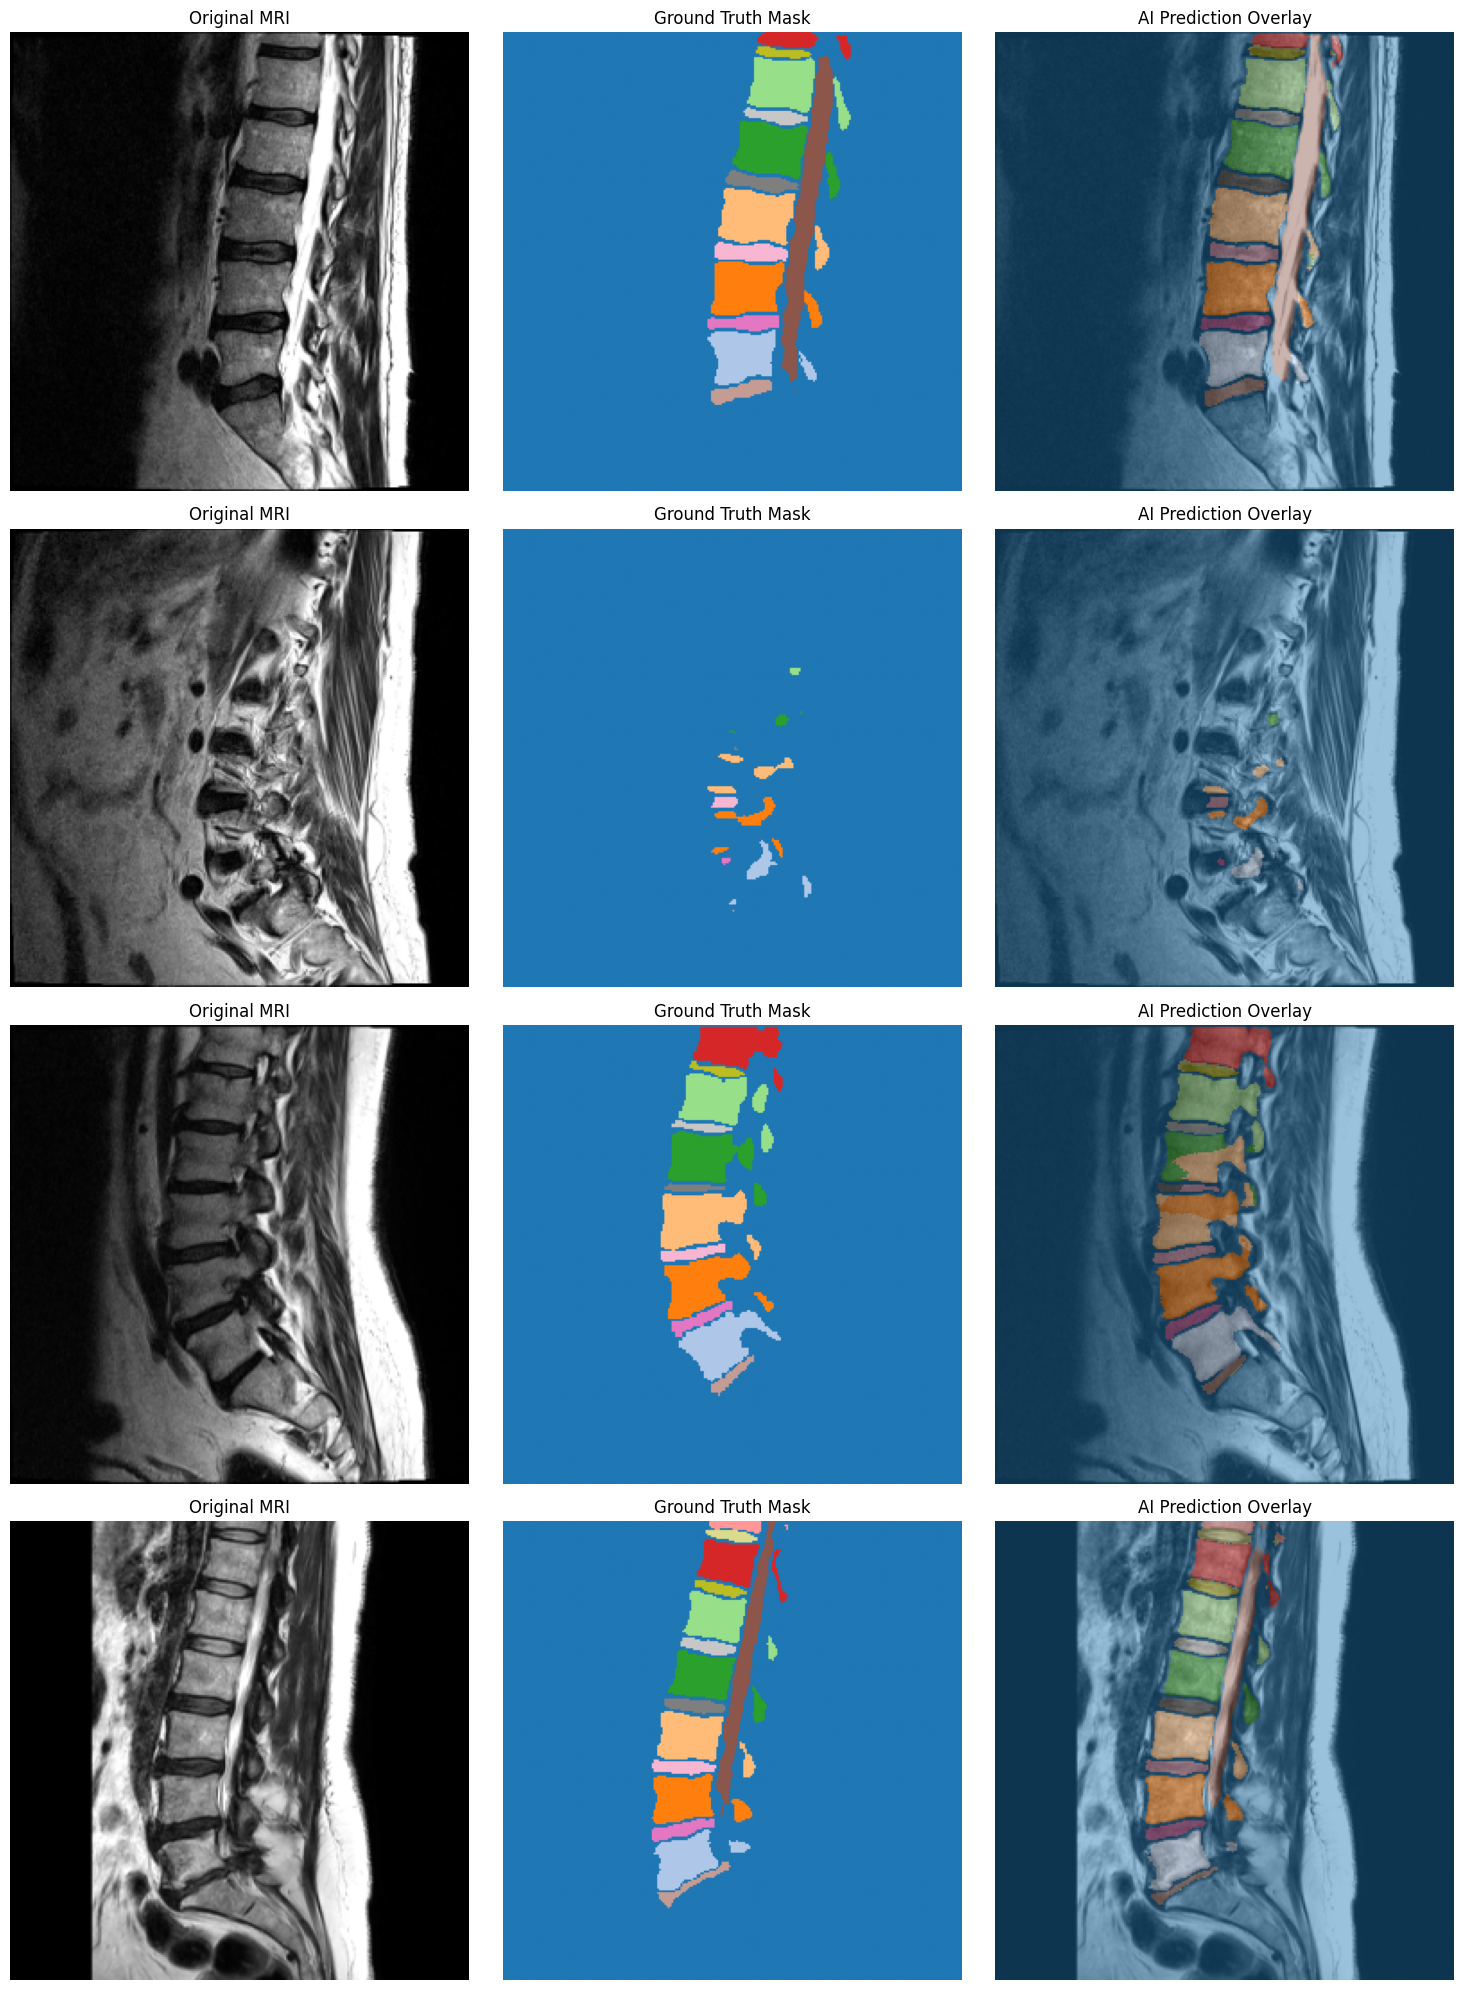

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Get one validation batch
images, true_masks = next(iter(val_dataset))

# Predict
predictions = model.predict(images, verbose=0)

# Convert probabilities → class labels
pred_masks = np.argmax(predictions, axis=-1)

# Show 4 examples
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for i in range(4):

    # Original MRI
    axes[i, 0].imshow(
        images[i, :, :, 0],
        cmap="gray"
    )
    axes[i, 0].set_title("Original MRI")
    axes[i, 0].axis("off")

    # Ground truth
    axes[i, 1].imshow(
        true_masks[i],
        cmap="tab20",
        vmin=0,
        vmax=19
    )
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    # Prediction
    axes[i, 2].imshow(
        images[i, :, :, 0],
        cmap="gray"
    )
    axes[i, 2].imshow(
        pred_masks[i],
        cmap="tab20",
        alpha=0.45,
        vmin=0,
        vmax=19
    )
    axes[i, 2].set_title("AI Prediction Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()